# Phân tích hội tụ của Robust Risk-Aware Bandit
Notebook này nạp dữ liệu từ các file `.npz` và vẽ đồ thị chi tiết cho từng chỉ số.

In [94]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import re

# 1. Cấu hình
results_root = "results"
n_list = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000]

color_map = {
    'robust': '#ff7f0e',        # Cam
    'quantile_risk': '#1f77b4', # Xanh dương
    'risk_lin_lcb': '#2ca02c',  # Xanh lá (Linear)
    'risk_exact': '#d62728' # Đỏ
}

label_map = {
    'risk_exact': 'Standar Neural',
    'risk_lin_lcb': ' LinLCB',
    'robust' : 'Risk aware Neural',
    'quantile_risk': 'Estimate G'

}

def get_algo_prefixes(data_dir):
    files = glob.glob(os.path.join(data_dir, "*.npz"))
    prefixes = set()
    for f in files:
        basename = os.path.basename(f)
        match = re.match(r"^(.*?)_(robust_syn|mushroom|insulin)_", basename)
        if match:
            prefixes.add(match.group(1))
    return sorted(list(prefixes))

def load_algorithms_from_dir(data_dir, n_list):
    prefixes = get_algo_prefixes(data_dir)
    all_results = {}
    all_files = glob.glob(os.path.join(data_dir, "*.npz"))
    
    for prefix in prefixes:
        summary = {'n_regret': [], 'n_extra': [], 'regret_mean': [], 'regret_std': [], 
                   'subopt_mean': [], 'subopt_std': [], 'gt_cvar_mean': [], 'gt_cvar_std': [],
                   'oracle_cvar': []}
        
        for n in n_list:
            target_files = []
            for f in all_files:
                fname = os.path.basename(f)
                if fname.startswith(prefix) and re.search(fr"_n={n}(_|\.npz)", fname):
                    target_files.append(f)
            
            if not target_files: continue
            d = np.load(target_files[0], allow_pickle=True)
            algo_name = d['algo_names'][0].replace(' ', '_') if 'algo_names' in d else prefix

            def get_d(s): 
                if algo_name and f"{algo_name}_{s}" in d: return d[f"{algo_name}_{s}"]
                return d[s] if s in d else None

            r = get_d('regrets')
            if r is not None:
                summary['n_regret'].append(n)
                summary['regret_mean'].append(np.mean(r))
                summary['regret_std'].append(np.std(r) / np.sqrt(len(r.flatten())))
            
            c = get_d('gt_cvars')
            if c is not None:
                summary['n_extra'].append(n)
                o_cvar = np.mean(d['oracle_cvars'])
                summary['gt_cvar_mean'].append(np.mean(c))
                summary['gt_cvar_std'].append(np.std(c) / np.sqrt(len(c.flatten())))
                sub = o_cvar - c
                summary['subopt_mean'].append(np.mean(sub))
                summary['subopt_std'].append(np.std(sub) / np.sqrt(len(c.flatten())))
                summary['oracle_cvar'].append(o_cvar)
        all_results[prefix] = summary
    return all_results

all_function_data = {}
for dname in os.listdir(results_root):
    if dname.startswith("robust_syn_") and os.path.isdir(os.path.join(results_root, dname)):
        parts = dname.split('_')
        if len(parts) >= 3:
            func_name = parts[2]
            full_path = os.path.join(results_root, dname)
            print(f"Loading data for function: {func_name} from {dname}")
            all_function_data[func_name] = load_algorithms_from_dir(full_path, n_list)
print("Dữ liệu của tất cả thuật toán đã nạp xong!")

Loading data for function: cosine from robust_syn_cosine_d=20_a=30_pi=eps-greedy0.1_std=0.1
Loading data for function: quadratic from robust_syn_quadratic_d=20_a=30_pi=eps-greedy0.1_std=0.1
Loading data for function: linear from robust_syn_linear_d=20_a=30_pi=eps-greedy0.1_std=0.1
Dữ liệu của tất cả thuật toán đã nạp xong!


In [95]:
def setup_neurips_style():
    plt.rcParams.update({
        "text.usetex": False,
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Times New Roman"],
        "axes.labelsize": 14,
        "font.size": 14,
        "legend.fontsize": 10,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "axes.titlesize": 16,
        "lines.linewidth": 2.5,
        "lines.markersize": 8,
        "figure.figsize": (7, 4.5),
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 100
    })

setup_neurips_style()

### 1. Biểu đồ Regret (Hội tụ kỳ vọng)
Kỳ vọng phần thưởng bị mất so với Oracle.

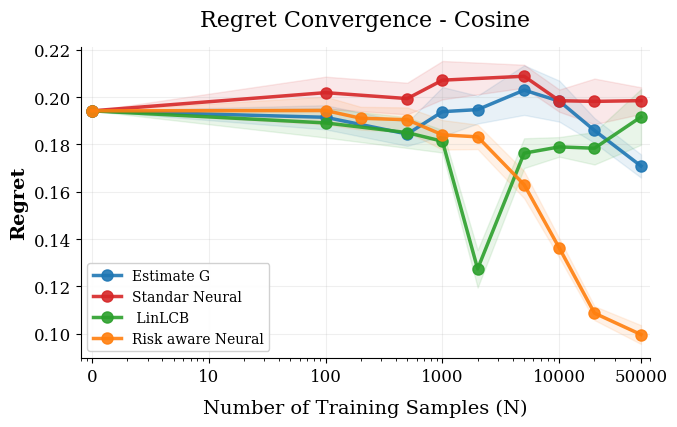

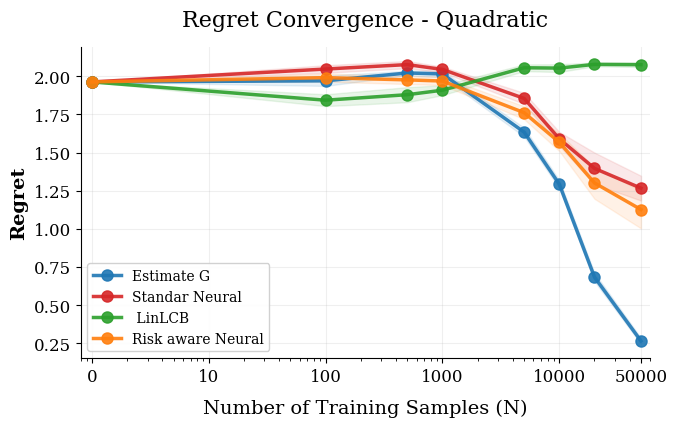

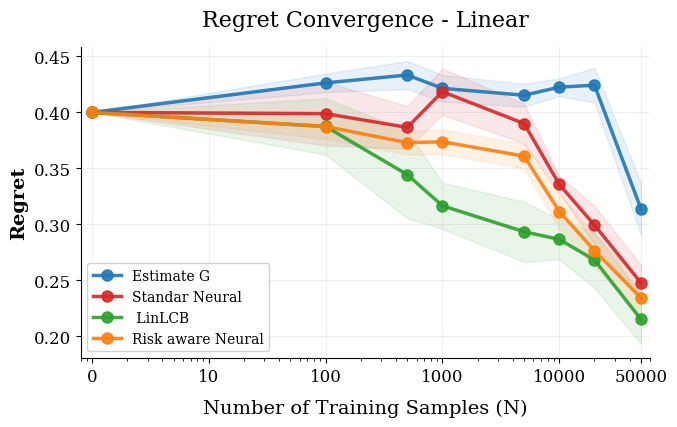

In [96]:
def plot_aligned_metric(func_name, summaries, metric='regret', title='Regret Comparison', ylabel='Regret'):
    setup_neurips_style()
    fig, ax = plt.subplots(figsize=(7, 4.5))
    
    # 1. Tính toán baseline chung tại điểm "bắt đầu"
    baselines = []
    for summary in summaries.values():
        m_key = 'regret_mean' if metric == 'regret' else 'subopt_mean'
        if summary[m_key]:
            baselines.append(summary[m_key][0])
    common_baseline = np.mean(baselines) if baselines else 0
    
    # Sử dụng x = 1 làm điểm đại diện cho "0" trên trục Log
    start_x = 1 

    for algo, summary in summaries.items():
        if metric == 'regret':
            x = np.array(summary['n_regret'])
            y = np.array(summary['regret_mean'])
            err = np.array(summary['regret_std'])
        elif metric == 'subopt':
            x = np.array(summary['n_extra'])
            y = np.array(summary['subopt_mean'])
            err = np.array(summary['subopt_std'])
        
        if len(x) == 0: continue
        
        # Chèn điểm bắt đầu ảo (x=1 tương ứng với nhãn 0)
        x_plot = np.insert(x, 0, start_x)
        y_plot = np.insert(y, 0, common_baseline)
        err_plot = np.insert(err, 0, 0)
        
        color = color_map.get(algo, '#333333')
        label = label_map.get(algo, algo)
        
        # Vẽ đường biểu diễn với marker
        line, = ax.plot(x_plot, y_plot, label=label, color=color, marker='o', 
                        markersize=8, markevery=1, alpha=0.9, linewidth=2.5)
        # Vẽ vùng sai số (Confidence Interval)
        ax.fill_between(x_plot, y_plot - 1.96*err_plot, y_plot + 1.96*err_plot, 
                        color=color, alpha=0.1)

    # 2. Định dạng trục X theo phong cách NeurIPS/Log-scale
    ax.set_xscale('log')
    
    # Thiết lập các mốc hiển thị cụ thể như trong hình mẫu
    tick_locs = [1, 10, 100, 1000, 10000, 50000]
    tick_labels = ['0', '10', '100', '1000', '10000', '50000']
    
    ax.set_xticks(tick_locs)
    ax.set_xticklabels(tick_labels)
    ax.set_xlim(0.8, 60000) # Đảm bảo điểm 0 hiển thị rõ
    
    # 3. Tinh chỉnh thẩm mỹ (Spines & Labels)
    ax.set_xlabel('Number of Training Samples (N)', fontsize=14, labelpad=10)
    ax.set_ylabel(ylabel, fontweight='bold', fontsize=14)
    ax.set_title(f'{title} - {func_name.capitalize()}', pad=15, fontsize=16)
    
    # Bật lưới nhẹ
    ax.grid(True, which='major', linestyle='-', alpha=0.2)
    
    # Legend
    ax.legend(frameon=True, loc='best', facecolor='white', framealpha=0.9, fontsize=10)
    
    plt.tight_layout()
    os.makedirs('plots', exist_ok=True)
    plt.savefig(f'plots/convergence_{func_name}_{metric}.pdf', bbox_inches='tight', dpi=300)
    plt.show()

# Thực thi vẽ
for func_name, summaries in all_function_data.items():
    plot_aligned_metric(func_name, summaries, metric='regret', title='Regret Convergence', ylabel='Regret')

### 2. Suboptimality Gap (Hội tụ rủi ro CVaR)
Giá trị này tiến về 0 nghĩa là thuật toán học được chính sách tối ưu về mặt rủi ro. Khoảng cách được tính bằng: `Oracle CVaR - Agent CVaR`.

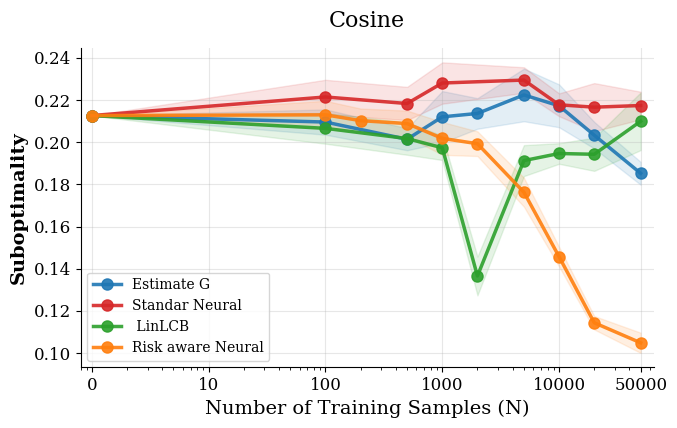

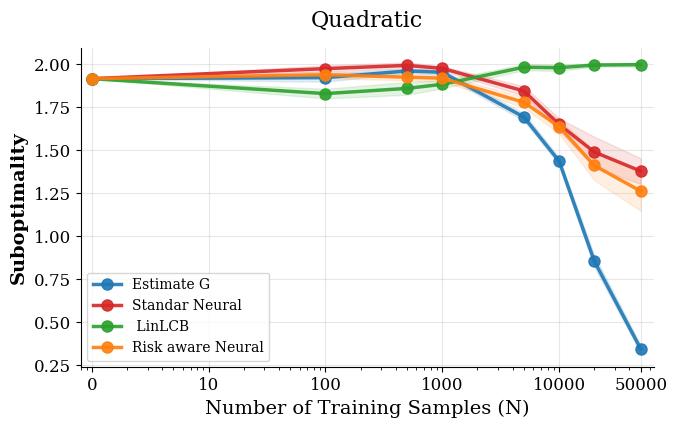

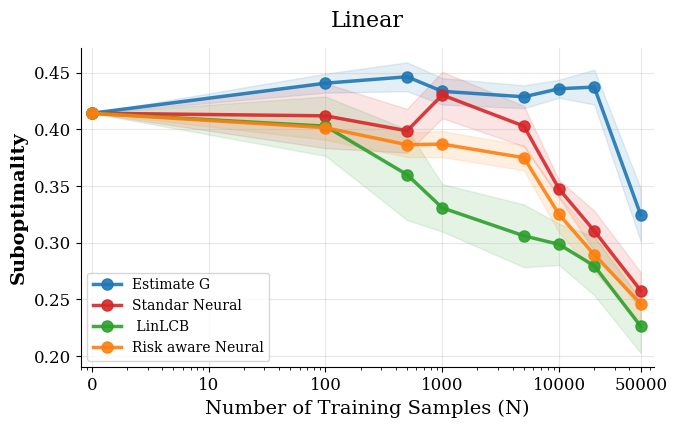

In [97]:
def plot_aligned_metric(func_name, summaries, metric='regret', title='Regret Comparison', ylabel='Regret'):
    setup_neurips_style()
    fig, ax = plt.subplots(figsize=(7, 4.5))
    
    # 1. Tính toán baseline chung từ giá trị đầu tiên của các thuật toán
    baselines = []
    for summary in summaries.values():
        m_key = 'regret_mean' if metric == 'regret' else 'subopt_mean'
        if summary[m_key]:
            baselines.append(summary[m_key][0])
    
    common_baseline = np.mean(baselines) if baselines else 0
    
    # Sử dụng 1 làm điểm bắt đầu ảo cho trục Log (để đại diện cho 0)
    # Vì log10(1) = 0, điểm này sẽ nằm ở vị trí bắt đầu của các lũy thừa cơ số 10
    start_x_pseudo = 1 
    
    for algo, summary in summaries.items():
        if metric == 'regret':
            x = np.array(summary['n_regret'])
            y = np.array(summary['regret_mean'])
            err = np.array(summary['regret_std'])
        elif metric == 'subopt':
            x = np.array(summary['n_extra'])
            y = np.array(summary['subopt_mean'])
            err = np.array(summary['subopt_std'])
        
        if len(x) == 0: continue
        
        # CHÈN ĐIỂM BẮT ĐẦU ẢO
        x_plot = np.insert(x, 0, start_x_pseudo)
        y_plot = np.insert(y, 0, common_baseline)
        err_plot = np.insert(err, 0, 0)
        
        color = color_map.get(algo, None)
        label = label_map.get(algo, algo)
        
        # Vẽ đường biểu diễn
        ax.plot(x_plot, y_plot, label=label, color=color, marker='o', 
                markevery=1, markersize=8, alpha=0.9, linewidth=2.5)
        
        # Vẽ vùng sai số
        ax.fill_between(x_plot, y_plot - 1.96*err_plot, y_plot + 1.96*err_plot, 
                        color=color, alpha=0.12)
    
    # 2. CẤU HÌNH TRỤC X THEO PHONG CÁCH NEURIPS (LOG SCALE)
    ax.set_xscale('log')
    
    # Thiết lập các vị trí Ticks mong muốn
    # Ta đặt tick tại 1 nhưng sẽ gán nhãn cho nó là "0"
    tick_locations = [1, 10, 100, 1000, 10000, 50000]
    tick_labels = ['0', '10', '100', '1000', '10000', '50000']
    
    ax.set_xticks(tick_locations)
    ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter()) # Tắt định dạng 10^n mặc định
    ax.set_xticklabels(tick_labels)
    
    # Điều chỉnh giới hạn trục để tránh bị mất điểm đầu/cuối
    ax.set_xlim(left=0.8, right=65000) 
    
    # 3. TINH CHỈNH THẨM MỸ
    ax.set_xlabel('Number of Training Samples (N)', fontsize=14)
    ax.set_ylabel(ylabel, fontweight='bold', fontsize=14)
    ax.set_title(f'{func_name.capitalize()}', pad=15, fontsize=16)
    
    # Lưới (Grid) nhẹ nhàng
    ax.grid(True, which='major', axis='both', linestyle='-', alpha=0.3)
    
    # Chú thích (Legend)
    ax.legend(frameon=True, loc='best', facecolor='white', framealpha=0.8, fontsize=10)
    
    plt.tight_layout()
    os.makedirs('plots', exist_ok=True)
    plt.savefig(f'plots/convergence_{func_name}_{metric}.pdf', bbox_inches='tight', dpi=300)
    plt.show()

for func_name, summaries in all_function_data.items():
    plot_aligned_metric(func_name, summaries, metric='subopt', title='CVaR Suboptimality', ylabel='Suboptimality')


### 3. So sánh Agent CVaR vs Oracle CVaR
Biểu đồ trực quan cho thấy mức độ an toàn của Agent so với giới hạn tối ưu của Oracle.

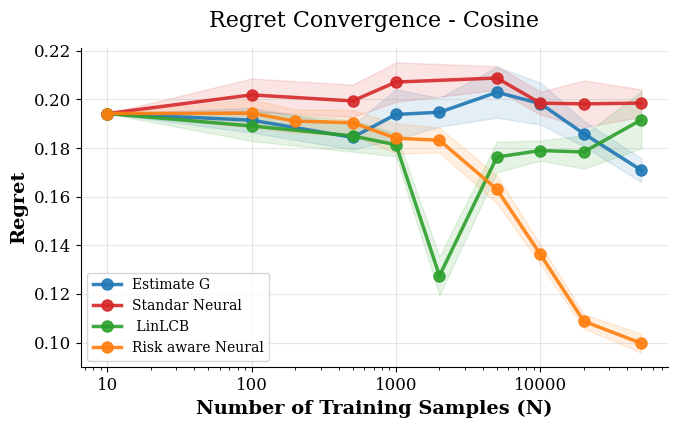

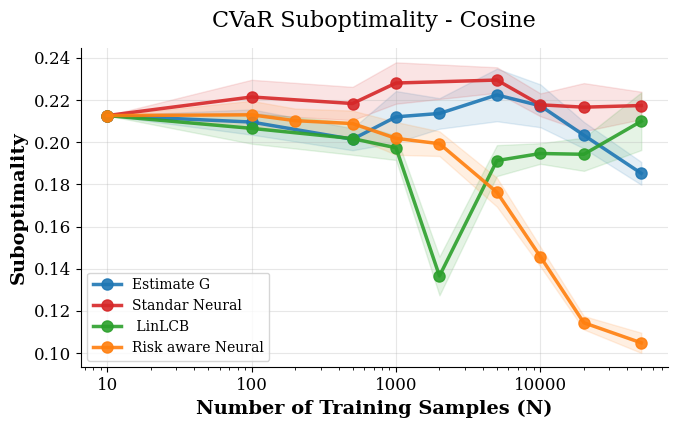

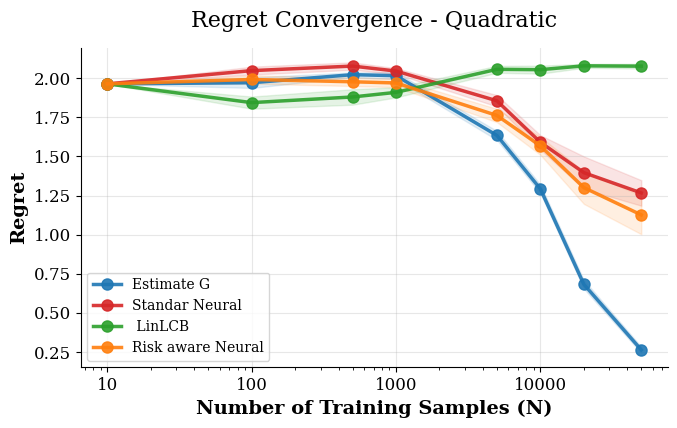

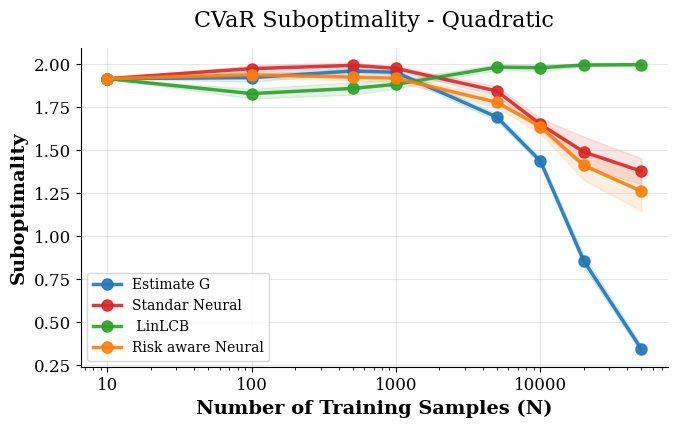

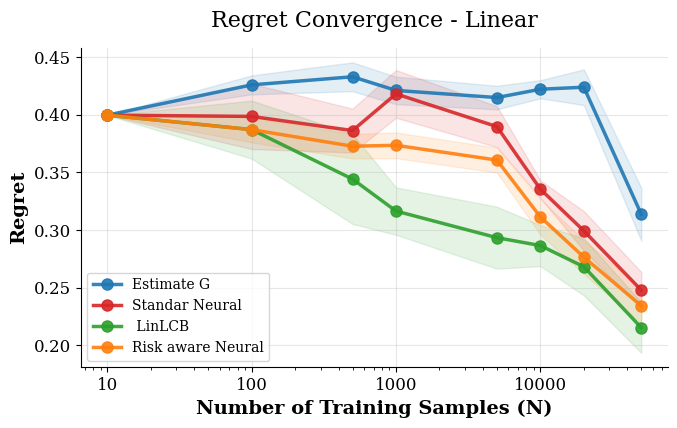

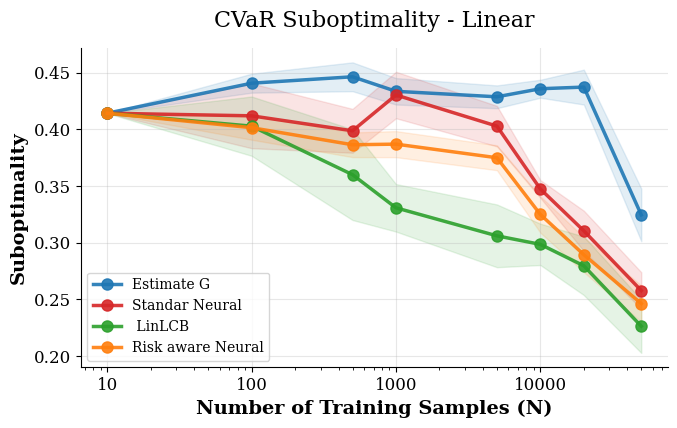

In [98]:
def plot_aligned_metric(func_name, summaries, metric='regret', title='Regret Comparison', ylabel='Regret'):
    setup_neurips_style()
    fig, ax = plt.subplots(figsize=(7, 4.5))
    
    # Calculate common starting point (baseline)
    # We'll use the maximum initial value as the common starting point at N=10
    start_n = 10
    baselines = []
    for summary in summaries.values():
        if metric == 'regret' and summary['regret_mean']:
            baselines.append(summary['regret_mean'][0])
        elif metric == 'subopt' and summary['subopt_mean']:
            baselines.append(summary['subopt_mean'][0])
    
    common_baseline = np.mean(baselines) if baselines else 0
    
    for algo, summary in summaries.items():
        if metric == 'regret':
            x = np.array(summary['n_regret'])
            y = np.array(summary['regret_mean'])
            err = np.array(summary['regret_std'])
        elif metric == 'subopt':
            x = np.array(summary['n_extra'])
            y = np.array(summary['subopt_mean'])
            err = np.array(summary['subopt_std'])
        
        if len(x) == 0: continue
        
        # PREPEND COMMON STARTING POINT
        # Add a point at start_n with the common_baseline to make them all start from one point
        x_plot = np.insert(x, 0, start_n)
        y_plot = np.insert(y, 0, common_baseline)
        err_plot = np.insert(err, 0, 0)
        
        color = color_map.get(algo, None)
        label = label_map.get(algo, algo)
        
        ax.plot(x_plot, y_plot, label=label, color=color, marker='o', markevery=max(1, len(x_plot)//6), alpha=0.9)
        ax.fill_between(x_plot, y_plot - 1.96*err_plot, y_plot + 1.96*err_plot, color=color, alpha=0.12)
    
    ax.set_xlabel('Number of Training Samples (N)', fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_title(f'{title} - {func_name.capitalize()}', pad=15)
    ax.set_xscale('log')
    
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    
    ax.legend(frameon=True, loc='best', facecolor='white', framealpha=0.8)
    plt.tight_layout()
    os.makedirs('plots', exist_ok=True)
    plt.savefig(f'plots/convergence_{func_name}_{metric}.pdf', bbox_inches='tight', dpi=300)
    plt.show()

for func_name, summaries in all_function_data.items():
    plot_aligned_metric(func_name, summaries, metric='regret', title='Regret Convergence', ylabel='Regret')
    plot_aligned_metric(func_name, summaries, metric='subopt', title='CVaR Suboptimality', ylabel='Suboptimality')
